## Digital and Computer Vision
### Lesson 2: Session 2

Thresholding, Edge Detection and Contours


### Summary of the previous session: Smoothing Techniques

In the previous session we have covered:

- Blurring and smoothing techniques: Average, Gaussian, Median, and Bilateral filters.
- Removing noise using image filtering.
- Histogram equalization for contrast enhancement.

### Summary of the current session: Thresholding, Edge Detection & Contours

In this session we will cover the following:

- Detecting edges using Sobel, Laplacian, and Canny edge detection.
- Finding and drawing contours in images.
- Thresholding, convex hulls, and shape approximations.
- Hough Transform.

### Exercise: from previous session

Apply histogram equalization with CLAHE.

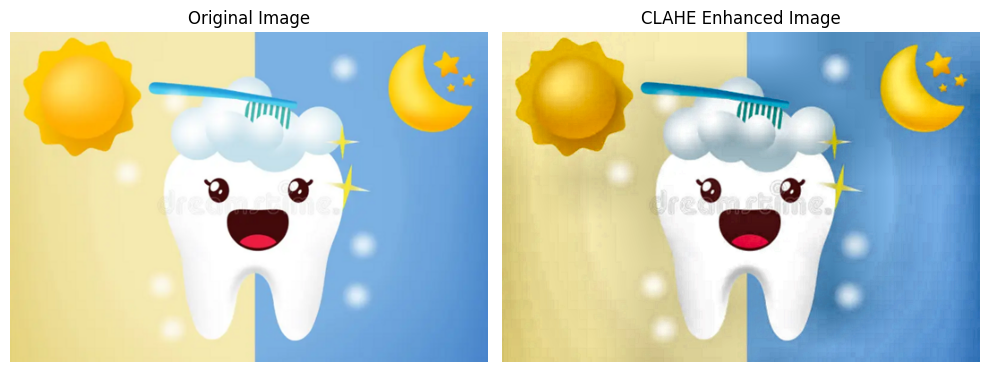

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


IMAGE_PATH = Path('download.png')


def load_image(path=IMAGE_PATH, flags=cv2.IMREAD_COLOR):
    path = Path(path)
    candidates = [
        path,
        Path.cwd() / path,
        Path.cwd().parent / path,
        Path('session3') / path.name,
        Path('../session3') / path.name,
    ]
    for candidate in candidates:
        if candidate.is_file():
            image = cv2.imread(str(candidate), flags)
            if image is not None:
                return image
    raise FileNotFoundError(f'Could not load image: {Path.cwd() / path}')


def show_images(images, titles, cols=None):
    cols = cols or min(3, len(images))
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(5 * cols, 4 * rows))
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        ax = plt.subplot(rows, cols, i)
        if img.ndim == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


color = load_image(flags=cv2.IMREAD_COLOR)
lab = cv2.cvtColor(color, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
cl = clahe.apply(l)
clahe_color = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)
show_images([color, clahe_color], ['Original Image', 'Equalized Color Image'], cols=2)


### Histogram theo vùng

Histogram cục bộ cho thấy phân bố mức xám trong từng vùng của ảnh. Ở đây ảnh được chia thành 4 phần để so sánh.

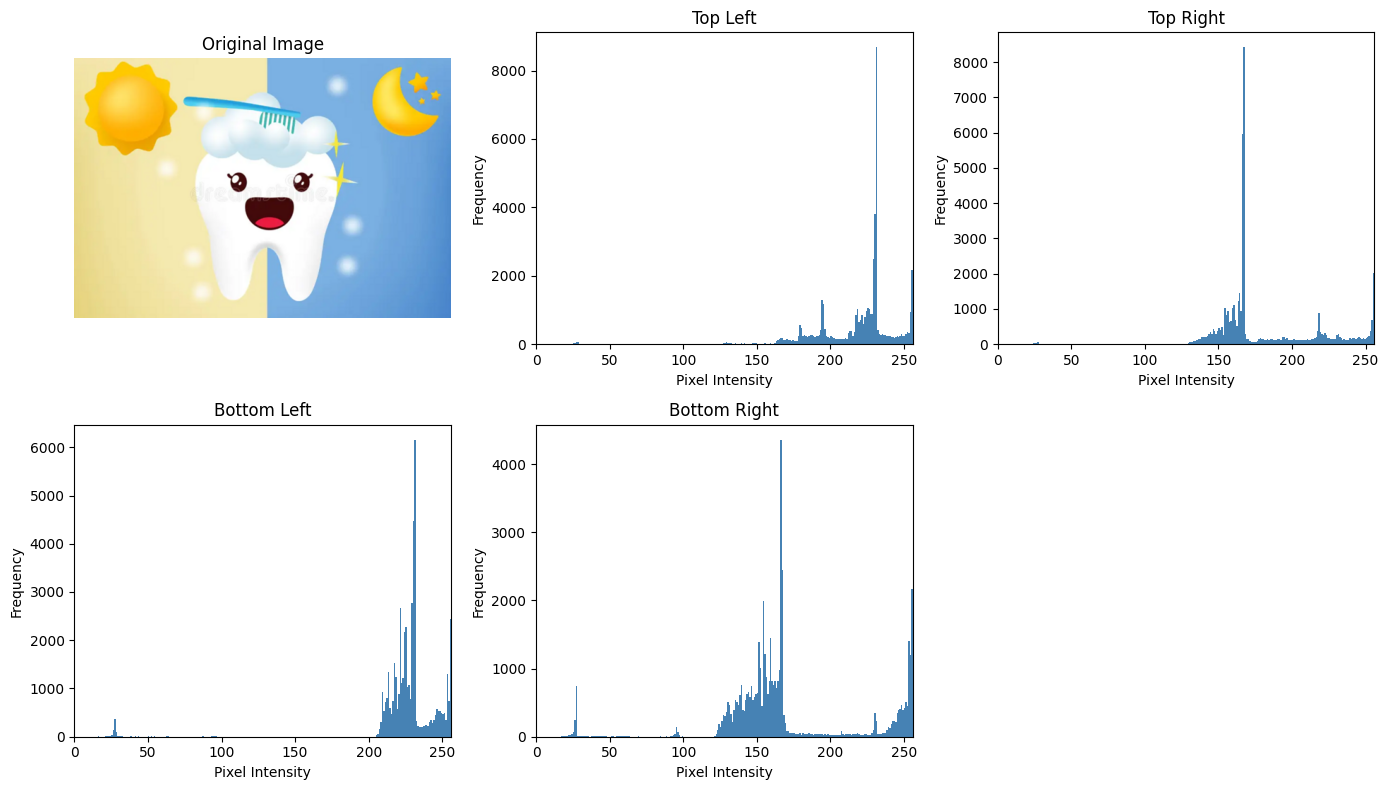

In [45]:
color = load_image(flags=cv2.IMREAD_COLOR)
gray = cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)

h, w = gray.shape
regions = {
    'Top Left': gray[:h // 2, :w // 2],
    'Top Right': gray[:h // 2, w // 2:],
    'Bottom Left': gray[h // 2:, :w // 2],
    'Bottom Right': gray[h // 2:, w // 2:],
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
axes[0].imshow(cv2.cvtColor(color, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

for ax, (name, region) in zip(axes[1:], regions.items()):
    ax.hist(region.ravel(), bins=256, range=(0, 256), color='steelblue')
    ax.set_title(name)
    ax.set_xlim(0, 256)
    ax.set_xlabel('Pixel Intensity')
    ax.set_ylabel('Frequency')

axes[-1].axis('off')
plt.tight_layout()
plt.show()


### Detecting edges using Sobel

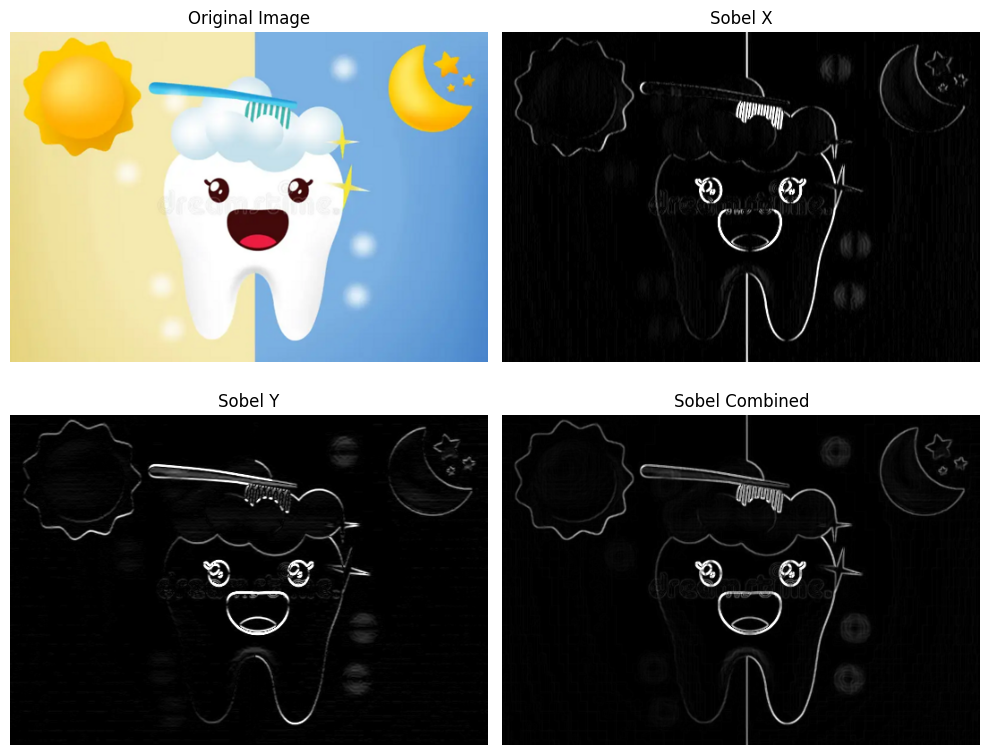

In [46]:
color = load_image(flags=cv2.IMREAD_COLOR)
image = cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)
sobel_combined = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)
show_images([color, sobel_x, sobel_y, sobel_combined], ['Original Image', 'Sobel X', 'Sobel Y', 'Sobel Combined'], cols=2)


### Canny edge detection example

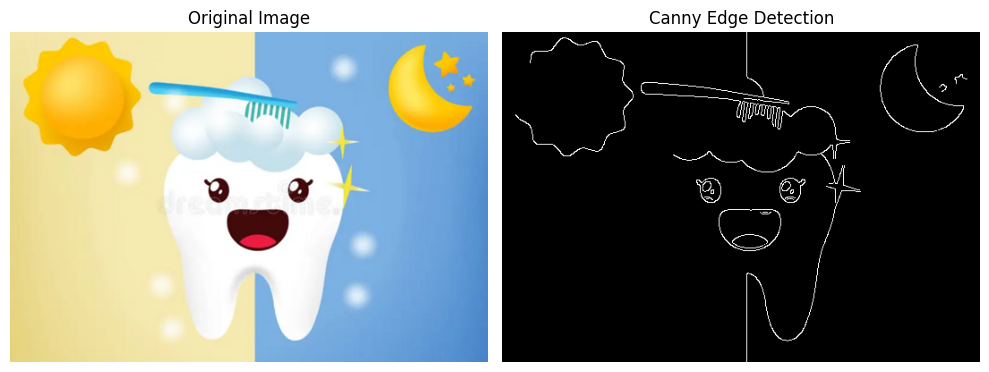

In [47]:
color = load_image(flags=cv2.IMREAD_COLOR)
image = cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(image, 100, 200)
show_images([color, edges], ['Original Image', 'Canny Edge Detection'], cols=2)


### Laplacian edge detection example

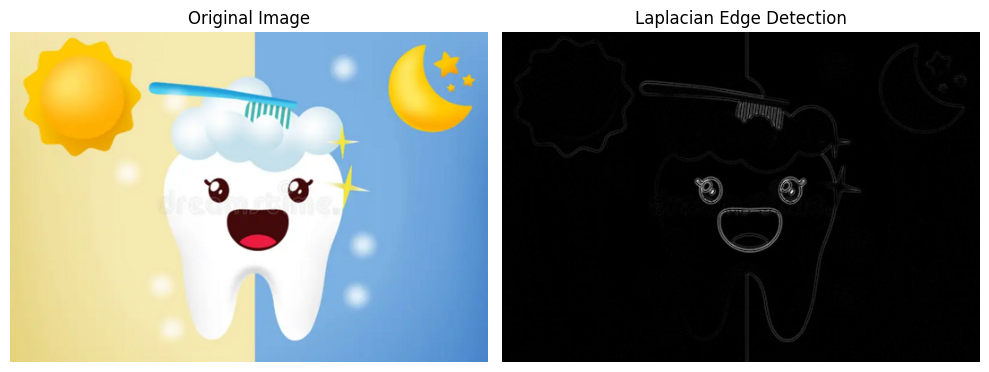

In [48]:
color = load_image(flags=cv2.IMREAD_COLOR)
image = cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(image, (3, 3), 0)
laplacian = cv2.Laplacian(blurred, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))
show_images([color, laplacian], ['Original Image', 'Laplacian Edge Detection'], cols=2)


### Simple thresholding example

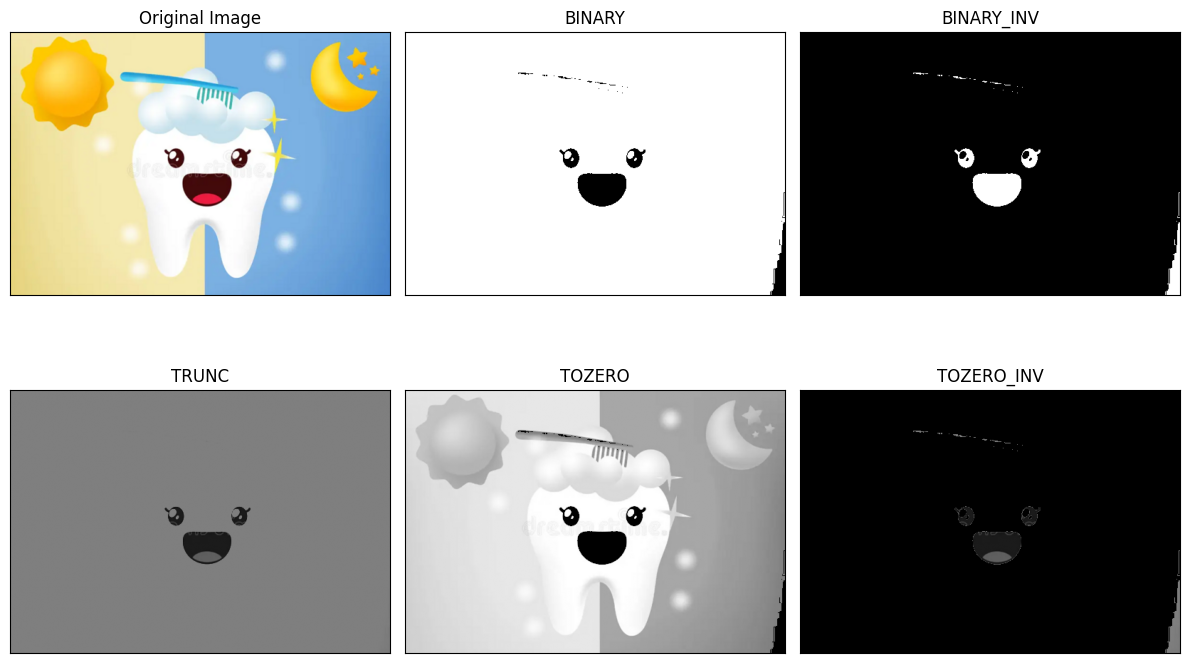

In [49]:
color = load_image(flags=cv2.IMREAD_COLOR)
image = cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)
ret, thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
ret, thresh2 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
ret, thresh3 = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)
ret, thresh4 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)
ret, thresh5 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)
titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [color, thresh1, thresh2, thresh3, thresh4, thresh5]
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    if images[i].ndim == 3:
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(images[i], 'gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


### Adaptive Thresholding example

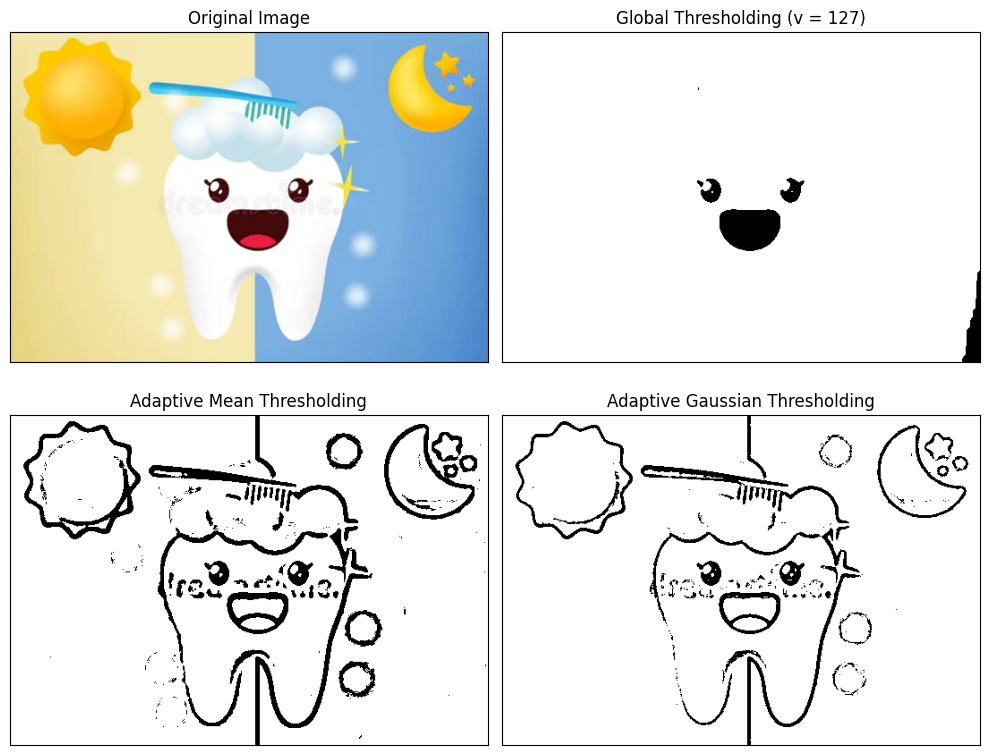

In [50]:
color = load_image(flags=cv2.IMREAD_COLOR)
image = cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)
image = cv2.medianBlur(image, 5)
ret, th1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
th2 = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
th3 = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
titles = ['Original Image', 'Global Thresholding (v = 127)', 'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [color, th1, th2, th3]
plt.figure(figsize=(10, 8))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    if images[i].ndim == 3:
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


### Otsu's Thresholding example

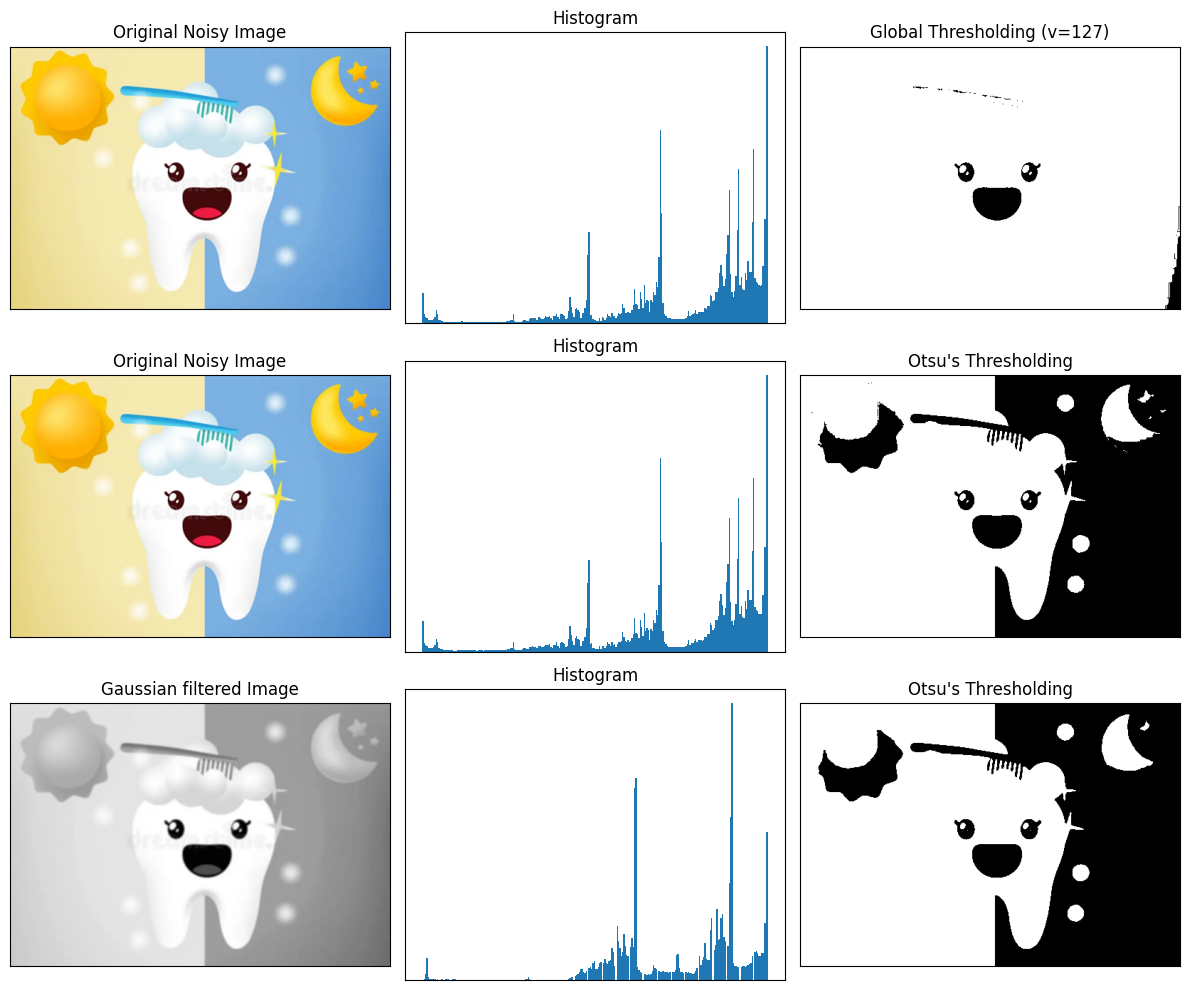

In [51]:
color = load_image(flags=cv2.IMREAD_COLOR)
img = cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)
ret1, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
ret2, th2 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
blur = cv2.GaussianBlur(img, (5, 5), 0)
ret3, th3 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
images = [color, 0, th1, color, 0, th2, blur, 0, th3]
titles = ['Original Noisy Image', 'Histogram', 'Global Thresholding (v=127)', 'Original Noisy Image', 'Histogram', "Otsu's Thresholding", 'Gaussian filtered Image', 'Histogram', "Otsu's Thresholding"]
plt.figure(figsize=(12, 10))
for i in range(3):
    plt.subplot(3, 3, i * 3 + 1)
    if images[i * 3].ndim == 3:
        plt.imshow(cv2.cvtColor(images[i * 3], cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(images[i * 3], 'gray')
    plt.title(titles[i * 3])
    plt.xticks([])
    plt.yticks([])
    plt.subplot(3, 3, i * 3 + 2)
    plt.hist(images[i * 3].ravel(), 256)
    plt.title(titles[i * 3 + 1])
    plt.xticks([])
    plt.yticks([])
    plt.subplot(3, 3, i * 3 + 3)
    plt.imshow(images[i * 3 + 2], 'gray')
    plt.title(titles[i * 3 + 2])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


### Finding and drawing contours example

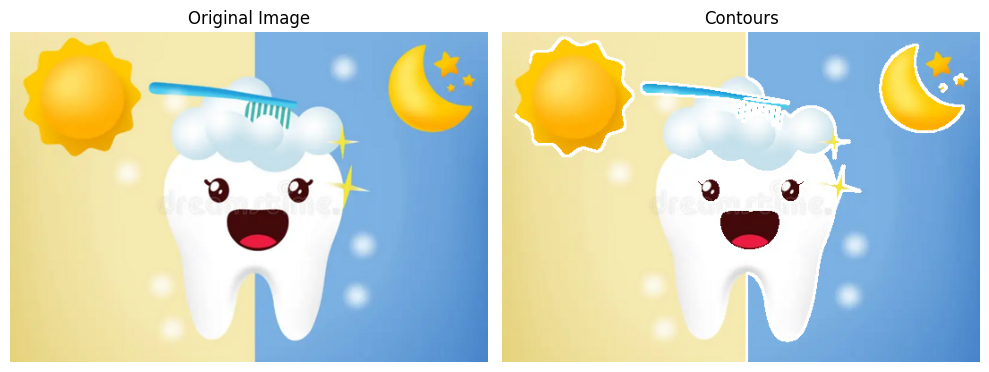

In [52]:
image = load_image(flags=cv2.IMREAD_COLOR)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 200)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
annotated = image.copy()
cv2.drawContours(annotated, contours, -1, (255, 255, 255), 2)
show_images([image, annotated], ['Original Image', 'Contours'], cols=2)


### Contour Features example

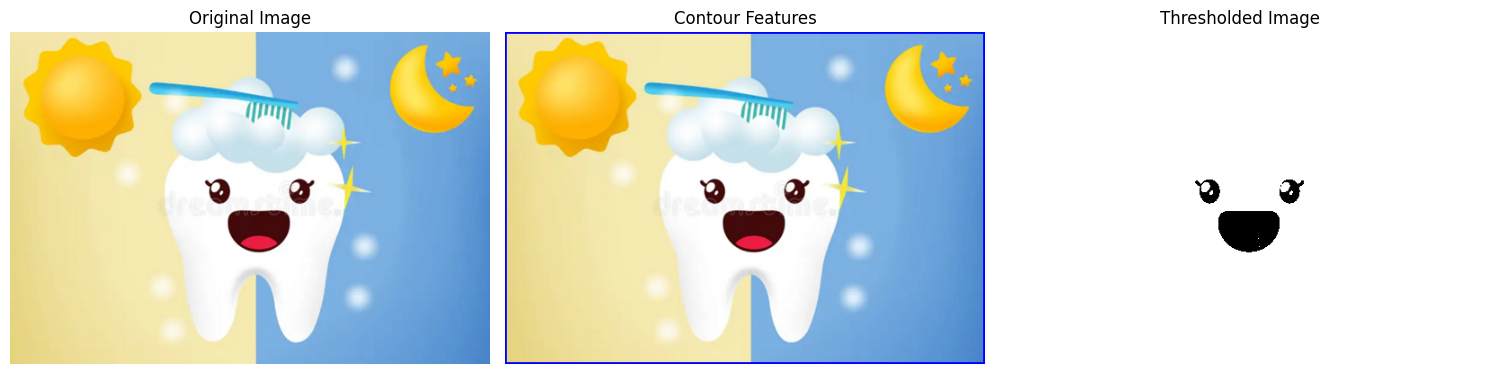

In [53]:
image = load_image(flags=cv2.IMREAD_COLOR)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
annotated = image.copy()
for contour in contours:
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = float(w) / h if h else 0
    hull = cv2.convexHull(contour)
    cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.drawContours(annotated, [hull], 0, (255, 0, 0), 2)
show_images([image, annotated, thresh], ['Original Image', 'Contour Features', 'Thresholded Image'], cols=3)


### Hough Line Transform example

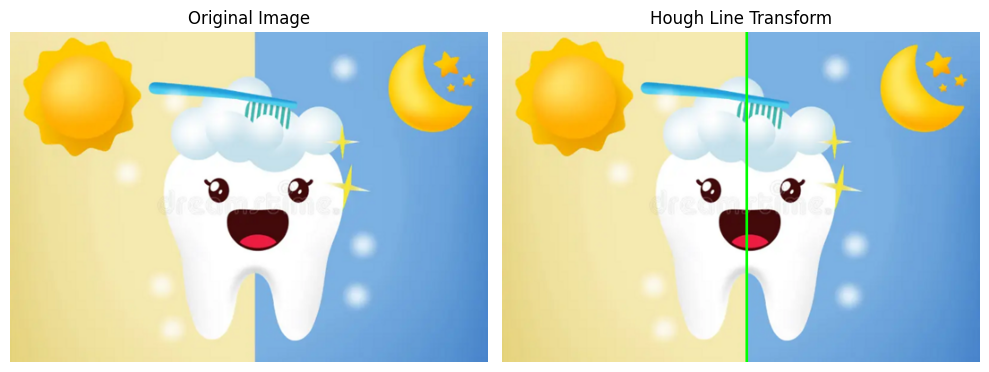

In [54]:
image = load_image(flags=cv2.IMREAD_COLOR)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)
lines = cv2.HoughLines(edges, 1, np.pi / 180, 150)
line_img = image.copy()
if lines is not None:
    for line in lines[:25]:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
show_images([image, line_img], ['Original Image', 'Hough Line Transform'], cols=2)


### Hough Circle Transform example

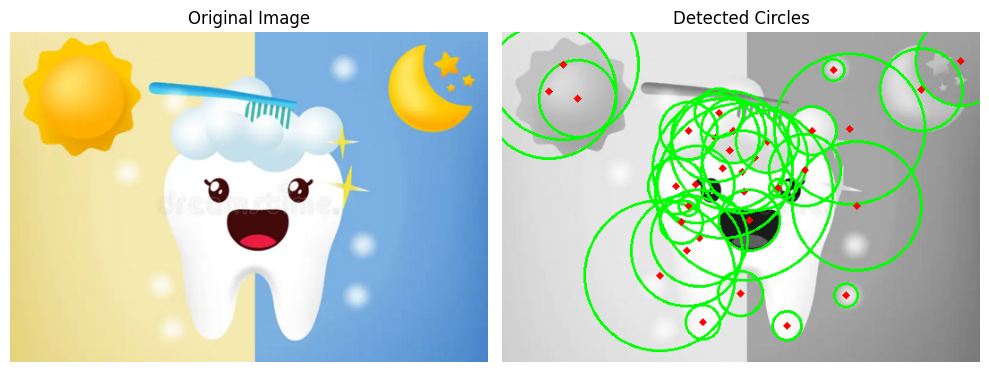

In [55]:
color = load_image(flags=cv2.IMREAD_COLOR)
img = cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)
cimg = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 20, param1=50, param2=30, minRadius=0, maxRadius=0)
if circles is None:
    h, w = img.shape
    circles = np.array([[[w // 2, h // 2, min(h, w) // 5]]], dtype=np.uint16)
else:
    circles = np.uint16(np.around(circles))
for i in circles[0, :]:
    cv2.circle(cimg, (i[0], i[1]), i[2], (0, 255, 0), 2)
    cv2.circle(cimg, (i[0], i[1]), 2, (0, 0, 255), 3)
show_images([color, cimg], ['Original Image', 'Detected Circles'], cols=2)
